<a href="https://colab.research.google.com/github/dorosholha/Modelling-DataAnalysis-Reporting/blob/main/Model_Fraud_Detection_PAYSIMDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROJECT: CONSTRUCTION OF A PREDICTIVE FRAUD MODEL ON PAYSIM DATASET**

🌐 **SOURCE OF THE DATASET:** https://www.kaggle.com/datasets/ealaxi/paysim1/data

🎯 **PROJECT OBJECTIVE:** build a predictive model that saves the company money by catching fraudsters, while minimizing false positives to avoid blocking honest customers

🔍 **DESCRIPTION DATAFRAME**:
*  `step`: maps a unit of time in the real world. Here, 1 step = 1 hour. Total steps = 744 (31 day simulation)
*  `type`: type of transaction (CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER)
*  `amount`: amount of the transaction in local currency
*  `nameOrig`: customer who started the transaction
*  `oldbalanceOrg`: initial balance of the sender before the transaction
* `newbalanceOrig`: balance of the sender after the transaction
*  `nameDest`: customer who receives the transaction
*  `oldbalanceDest`: initial balance of the recipient before the transaction (no information for customers starting with 'M' = Merchants)
*  `newbalanceDest`: balance of the recipient after the transaction (no information for customers starting with 'M' = Merchants)
*  `isFraud`: indicates if the transaction id fraudolent (1 = true, 0 = false). In this dataset, fraud happens when an attacker takes control of a bank account, transfers money to another account (`TRANSFER`)
and then withdraws it (`CASH_OUT`)





In the following section, I will import the libraries we need for data analysis

In [ ]:
import kagglehub #source of dataset
import pandas as pd #to manage dataframe
import os #to manage files in dataset
import numpy as np #to manage arrays
import matplotlib.pyplot as plt #to manage charts
import seaborn as sns #to make beautiful charts
from sklearn.model_selection import train_test_split #to split the dataset in train + test
from sklearn.metrics import classification_report, confusion_matrix #report and evalutation of results
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score #AUC & AUPRC
from sklearn.preprocessing import StandardScaler #to shrink all numbers (eg. amounts and hours) to the same scale
from sklearn.linear_model import LogisticRegression #model 1 (Logistic Regression)
from sklearn.ensemble import RandomForestClassifier #model 2 (Random Forest)
from xgboost import XGBClassifier #model 3 (XGBoost)


#Download and import dataset from Kaggle (https://www.kaggle.com/datasets/ealaxi/paysim1/data)
temp_path = kagglehub.dataset_download("ealaxi/paysim1")
#New path
path=os.path.join(temp_path, "PS_20174392719_1491204439457_log.csv")
df=pd.read_csv(path)

#DATA CLEANING
print(df.shape) #(6362620 rows, 11columns)
#Delete columns oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest
df=df.drop(columns=["oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"])
#print(df.shape) #(6362620 rows, 7columns)
#df.head()
#df.isna().sum() #There aren't NA
df["amount_log"] = np.log1p(df["amount"]) #The same chart with the "amount" variable isn't very good because the data is highly skewed.
                                          #To address this, I transformed the variable using a logarithmic scale, which allows large values to be compressed and small differences to be expanded
df = df[df["type"].isin(["TRANSFER", "CASH_OUT"])] #keep only the rows with "type" = "TRANSFER" OR "CASH_OUT"
#FEATURE ENGINEERING
df["hour_of_day"]=df["step"] % 24
df["day_of_week"] = (df["step"] // 24) % 7
#test = df[df["step"]==100]
#print(test)




Using Colab cache for faster access to the 'paysim1' dataset.
(6362620, 11)


Absolute and Relative Frequency of Transactions (Legitimate vs Fraudulent):
            Absolute Frequency  Relative Frequency(%)
isFraud                                              
Legitimate             2762196              99.703546
Fraud                     8213               0.296454




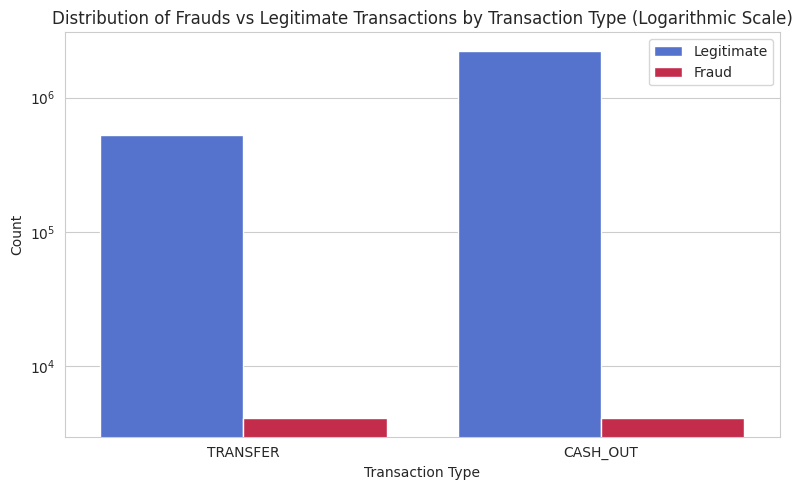

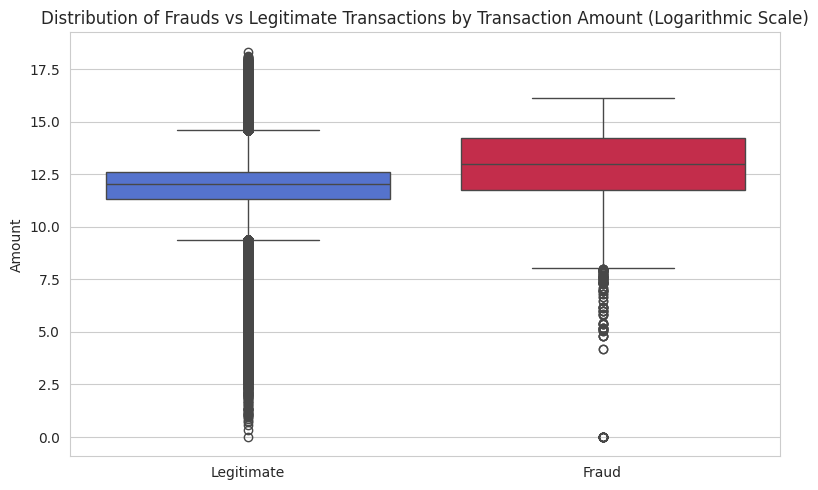

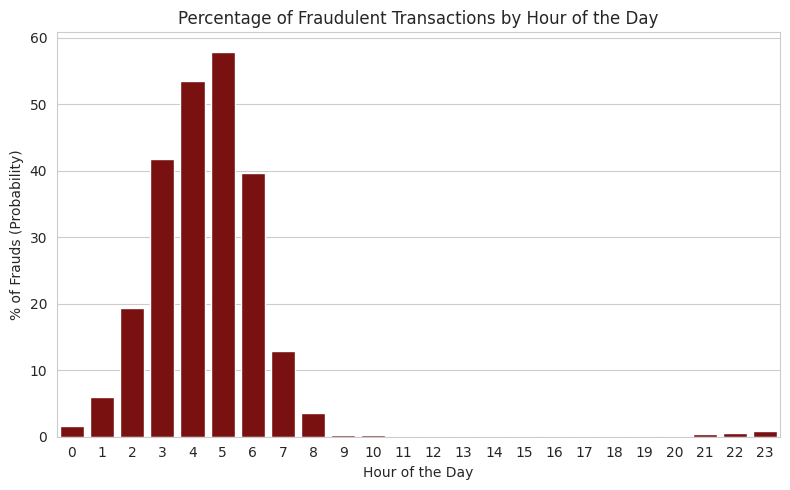

In [ ]:

"""--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
EXPLORATORY DATA ANALYSIS (EDA)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------"""

#Set theme
sns.set_style("whitegrid")
#Set color --> blue for Legitimate Tx, Red for Fraudolent Tx
custom_palette = {0: "royalblue", 1: "crimson"}

#Absolute & Relative Frequencies Table
print("Absolute and Relative Frequency of Transactions (Legitimate vs Fraudulent):")
freq = pd.DataFrame({
    "Absolute Frequency": df["isFraud"].value_counts(),
    "Relative Frequency(%)": df["isFraud"].value_counts(normalize=True)*100
})
freq.index = freq.index.map({0: "Legitimate", 1: "Fraud"})
print(freq)
print("\n")

#Distribution of transaction type by isFraud (log scale)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type", hue="isFraud", palette=custom_palette)
plt.yscale("log")
plt.title("Distribution of Frauds vs Legitimate Transactions by Transaction Type (Logarithmic Scale)")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
new_labels = ["Legitimate", "Fraud"]
leg = plt.legend(title=None)
for t, l in zip(leg.texts, new_labels):
    t.set_text(l)
plt.tight_layout()
plt.show()
print("\n")

#Boxplot (log scale)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="isFraud", y="amount_log", hue="isFraud", palette=custom_palette, legend=False)
plt.xlabel("")
plt.title("Distribution of Frauds vs Legitimate Transactions by Transaction Amount (Logarithmic Scale)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.ylabel("Amount")
plt.tight_layout()
plt.show()
print("\n")

#Distribution of frauds throughout the day
plt.figure(figsize=(8, 5))
fraud_by_hour = df.groupby("hour_of_day")["isFraud"].mean() * 100 #Special case. Since the variable "isFraud" is a binary variable (0/1), calculating its mean directly yields the percentage of fraudulent
                                                                  #transactions for each hour
sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, color="darkred")
plt.title('Percentage of Fraudulent Transactions by Hour of the Day')
plt.xlabel("Hour of the Day")
plt.ylabel("% of Frauds (Probability)")
plt.tight_layout()
plt.show()
print("\n")

To get the data ready for Machine Learning, I did the following:

1.   Removed identifiers like account names that do not help the model predict fraud
2.   Converted categorical features into numbers using One-Hot Encoding (`TRANSFER` = `true` & `CASH_OUT` = `false`)
3.   Split the data into training and testing sets



**EDA**

Before looking at the charts, it is important to understand that **our data is very unbalanced**. Out of about 2.8 million transactions, only 8213 are fraud. This is just 0.29% (please, see the table below for more info).

Because of this big difference, we have to use a logarithmic scale in the charts. On a normal scale, fraud cases would be almost impossible to see. A logarithmic scale makes large numbers smaller and small numbers easier to see.


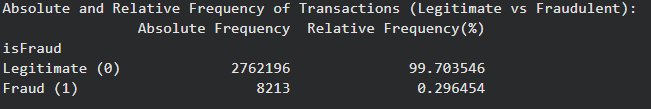

In the following chart, we see how transaction types are distributed, divided into legitimate (in blue) and fraudulent (in red) ones. Fraud cases are much fewer than normal transactions.

We can also observe that the number of fraud cases for the transaction types `TRANSFER` and `CASH_OUT` is almost identical. This is not accidental. Indeed attackers typically take control of an account (Account Takeover, ATO), transfer the money to a new “mule” account, and immediately withdraw it to make it disappear. Since each fraudulent event usually involves both steps, it is normal that the counts for both transaction types in fraudulent cases are similar.

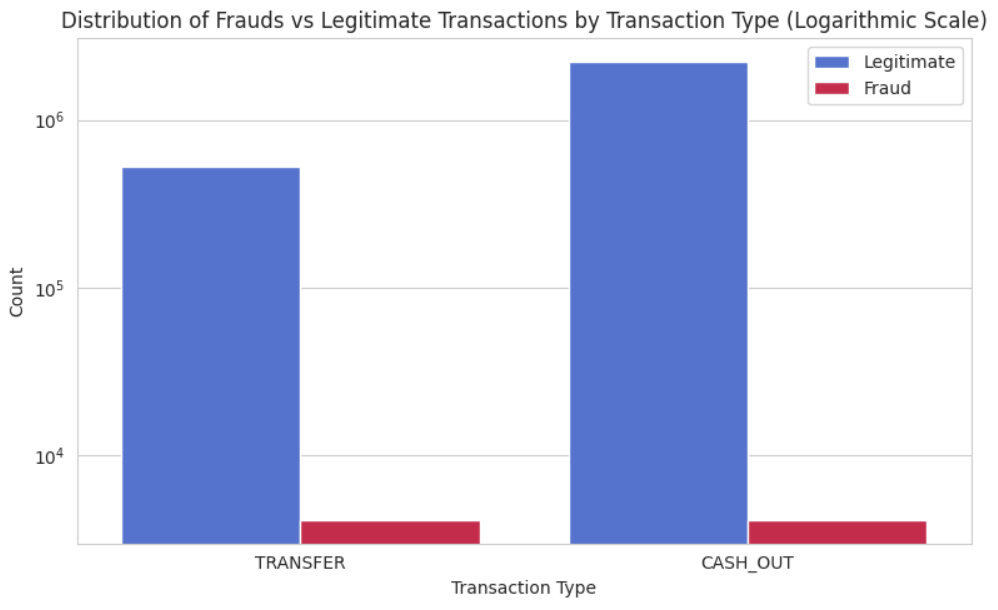

In this chart, we can see that **fraudulent transactions usually have higher amounts than normal ones**. The median (the line inside the box) for fraud is higher than for legitimate transactions.

Legitimate transactions are more regular and predictable. The blue box is small, which means most values are similar and close to each other.

On the other hand, fraudulent transactions are more spread out. The red box is taller, showing a lot of variation. This means there is no typical fraud amount. Probably, criminals usually try to take as much money as possible from each account.

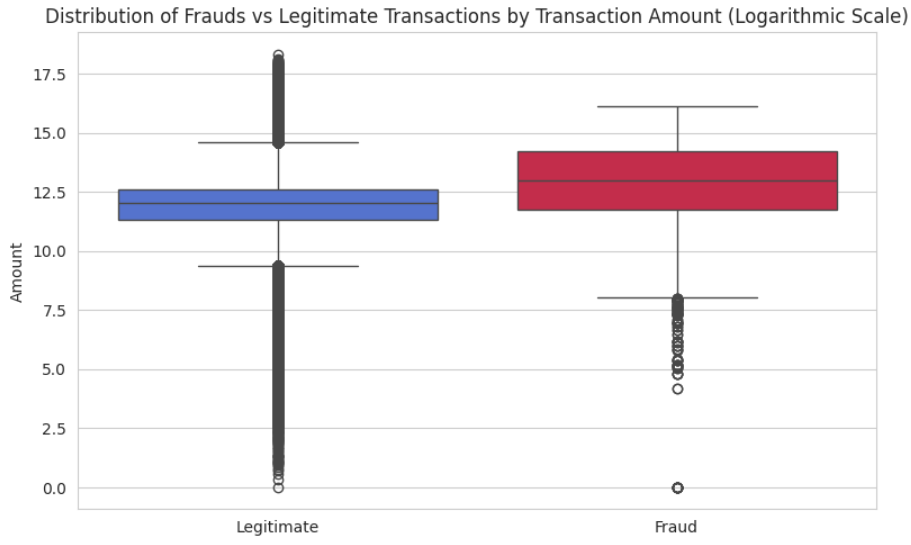

The following chart shows that most **fraud happens between 3 AM and 6 AM, with a peak at 5 AM**, when almost 60% of transactions are fraudulent.

From 9 AM to midnight, the chance of fraud is very low, because many normal transactions happen during the day and evening. This pattern is not random. Criminals often act during the night, when people are asleep and less likely to notice. They also take advantage of times when monitoring systems may be less active or more automated.


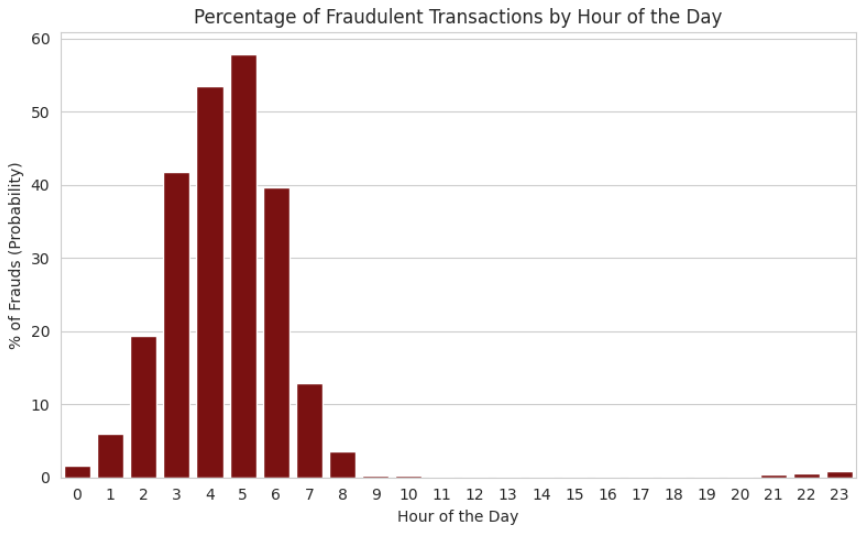

In [ ]:
#DATA PREPARATION
#Drop unnecessary variables
columns_to_drop = ["step", "nameOrig", "nameDest", "isFlaggedFraud", "amount"]
df = df.drop(columns=columns_to_drop, errors="ignore")

#One-Hot Encoding for the "type" (=converts categorical TRANSFER/CASH_OUT to 1/true or 0/false)
df = pd.get_dummies(df, columns=["type"], drop_first=True)
#display(df.head(5))
#Define Features (X) and Target (y)
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

#Train-Test Split (stratify is crucial to maintain the same fraud ratio in train and test sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
#Train set size: 2216327
#Test set size: 554082

Train set size: 2216327
Test set size: 554082


**MODEL SELECTION**

For this fraud detection project, I will start from a simple and moving to more advanced models if needed.
 1. **Logistic Regression**

I begin with a simple model to understand the problem. Logistic Regression is the baseline for binary classification (Fraud vs Legitimate). If it performs well, there’s no need for more complex models


 2. **Random Forest**

If Logistic Regression is not enough, I will move to Random Forest. For tabular data like ours, it often works very well. Random Forest can detect complex patterns, for example: “IF the amount is high AND the time is 3 AM, then likely fraud.” It builds hundreds of decision trees that "vote" together, reducing errors and false positives. Random Forest also handles imbalanced data effectively using the `class_weight`=`balanced` parameter, giving more importance to rare fraud cases

 3. **XGBoost**

If Random Forest is too cautious and misses some frauds, I will use XGBoost (Extreme Gradient Boosting). Unlike Random Forest, which builds all trees independently at once, XGBoost builds trees sequentially, with each new tree correcting the mistakes of the previous ones. This step-by-step learning makes XGBoost extremely powerful, especially for highly unbalanced datasets and often gives the best results in detecting rare fraud cases (but we need to pay attention because this model tends to overfit the data)




**MODEL EVALUATION**

Because our dataset is highly imbalanced (frauds are much fewer than legitimate transactions), we need to use the right metrics to evaluate the models.

Accuracy is misleading.
A model that predicts “Legitimate” for every transaction would have 99.8% accuracy. It looks perfect, but it wouldn’t catch any fraud. Instead, we use metrics designed for imbalanced data.

**Confusion Matrix**

We start with the Confusion Matrix, which summarizes model predictions at a fixed probability threshold (usually 50%). It has four categories:

*  True Positives (TP): frauds correctly detected
*  False Positives (FP): legitimate transactions incorrectly flagged as fraud (false alarms)
*  True Negatives (TN): legitimate transactions correctly identified
*  False Negatives (FN): frauds that were missed



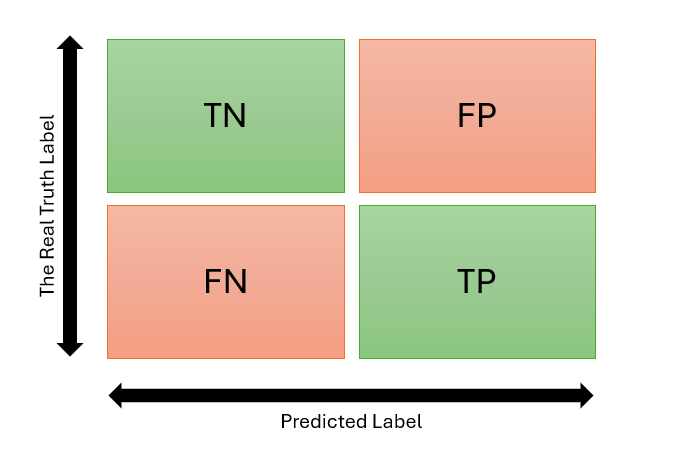

These values are the basis for metrics like **Precision, Recall, and F1-Score**, which are much more informative for rare-event detection like fraud.

* **Recall:** out of all the actual frauds, how many did we catch?

$$Recall = \frac{TP}{TP + FN}$$

* **Precision:** out of all the transactions we flagged as fraud, how many were actually frauds?

$$Precision = \frac{TP}{TP + FP}$$

* **F1-Score:** harmonic mean of Precision and Recall, giving us a single balanced score for the Fraud class

$$F1 = \frac{2 \times TP}{2 \times TP + FP + FN}$$


**AUPRC (Area Under the Precision-Recall Curve):**


While the Confusion Matrix shows performance at a single threshold, we also want to see how the model performs across all thresholds. For this, we use AUPRC (Area Under the Precision-Recall Curve). This metric summarizes the trade-off between Precision and Recall at different thresholds. A higher AUPRC means the model is better at identifying frauds while keeping false alarms low.






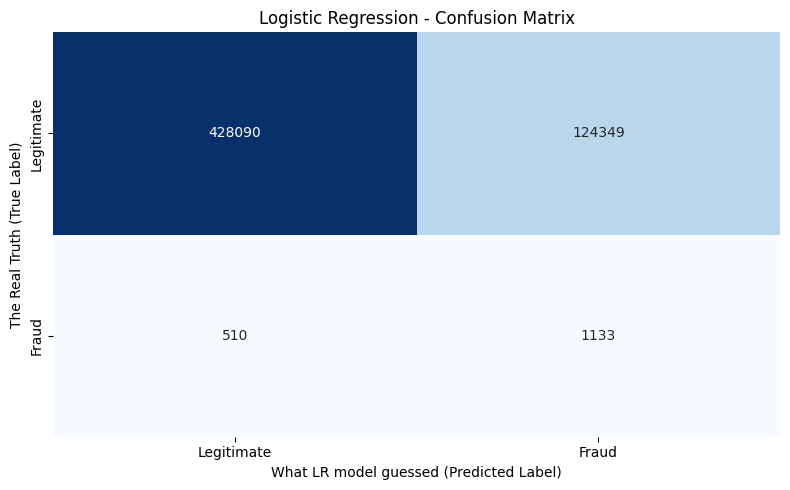


Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.77      0.87    552439
       Fraud       0.01      0.69      0.02      1643

    accuracy                           0.77    554082
   macro avg       0.50      0.73      0.45    554082
weighted avg       1.00      0.77      0.87    554082

AUC-ROC Score: 0.7801 (probably inflated by TN)
AUPRC Score:   0.0230 (real performance on frauds)



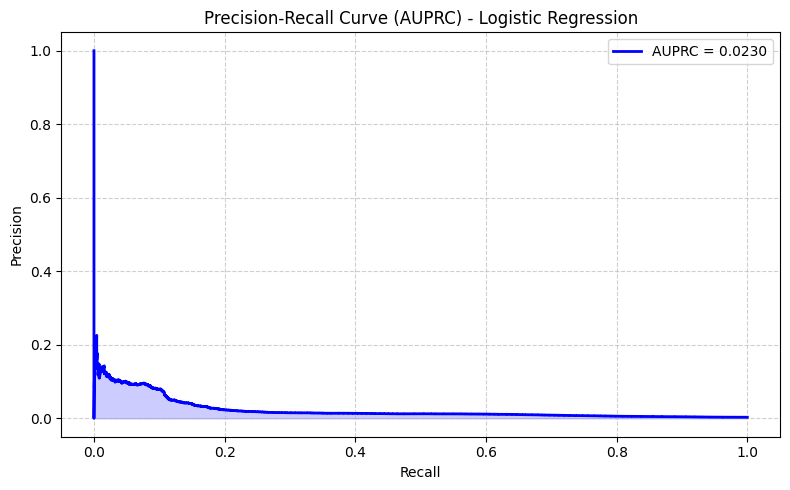

In [ ]:
#LOGISTIC REGRESSION

#Data scaling
#We need to shrink all numbers (eg. amounts and hours) to the same scale
scaler = StandardScaler()
#fit_transform on Train set --> learns the rule (fit) + modifies the numbers (transform) all at once
X_train = scaler.fit_transform(X_train)
#transform ONLY on Test set--> NO "fit" here, otherwise the model would cheat by peeking at the "exam"(Data Leakage)
X_test = scaler.transform(X_test)

#Train the LR model
#"class_weight=balanced", this parameter helps the LR model to automatically determine the right penalty to give the model when it makes a mistake
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

#LR have to analyze the scaled data and the answers to learn how to spot cyber criminals
lr.fit(X_train, y_train)

#Predictions
y_pred_lr = lr.predict(X_test)
# Probabilities (the model's confidence scores) --> we need them for the AUPRC
# We use predict_proba() and take only column 1 (the fraud cases)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

#Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 5))
class_labels = ["Legitimate", "Fraud"]
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("What LR model guessed (Predicted Label)")
plt.ylabel("The Real Truth (True Label)")
plt.tight_layout()
plt.show()

#Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=["Legitimate", "Fraud"]))

#AUC & AUPRC
roc_auc = roc_auc_score(y_test, y_prob_lr)
auprc_score = average_precision_score(y_test, y_prob_lr)
print(f"AUC-ROC Score: {roc_auc:.4f} (probably inflated by TN)") #looks high but the TN inflates the performance
print(f"AUPRC Score:   {auprc_score:.4f} (real performance on frauds)\n")
#Chart of AUPRC Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color="blue", lw=2, label=f'AUPRC = {auprc_score:.4f}')
plt.fill_between(recall, precision, alpha=0.2, color="blue")
plt.title("Precision-Recall Curve (AUPRC) - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Logistic Regression Results**

The Confusion Matrix above shows the classification errors made by the Logistic Regression model. The biggest issue is the large number of False Positives (124349). The model is too sensitive and incorrectly flags many legitimate transactions, creating too many false alarms.
On the positive side, the model correctly detected 1133 frauds (True Positives), but it missed 510 frauds (False Negatives).

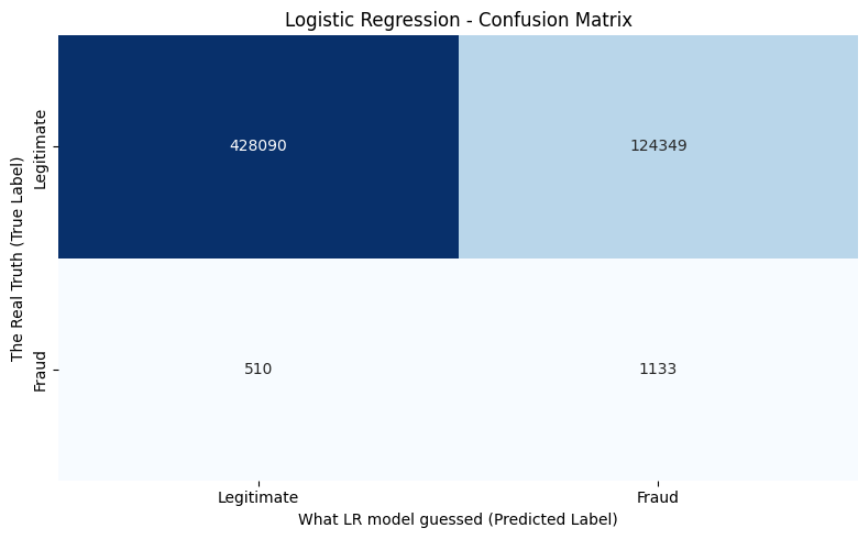


**Classification Report**:

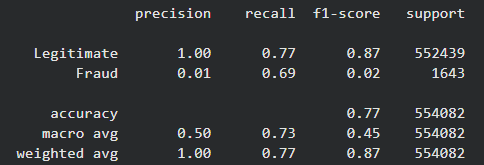

While the overall Accuracy (0.77%) might look ok, it is a misleading metric in this case due to the highly imbalanced dataset. We must focus on the Fraud row:

* Recall (0.69): the model catches 69% of the actual frauds. It is a reasonable starting point, but not the ideal
* Precision (0.01): only 1% of the flagged transactions are actual frauds. The model is creating a massive amount of false alarms (blocking honest customers)
* F1-Score (0.02): this extremely low score confirms that the model's overall performance on the minority class is poor due to the terrible precision.

The Precision-Recall Curve also drops quickly. Trying to catch more frauds (higher Recall) results in many more mistakes (lower Precision). **The AUPRC score of 0.0230 confirms that Logistic Regression is too simple to handle such a highly unbalanced dataset**.

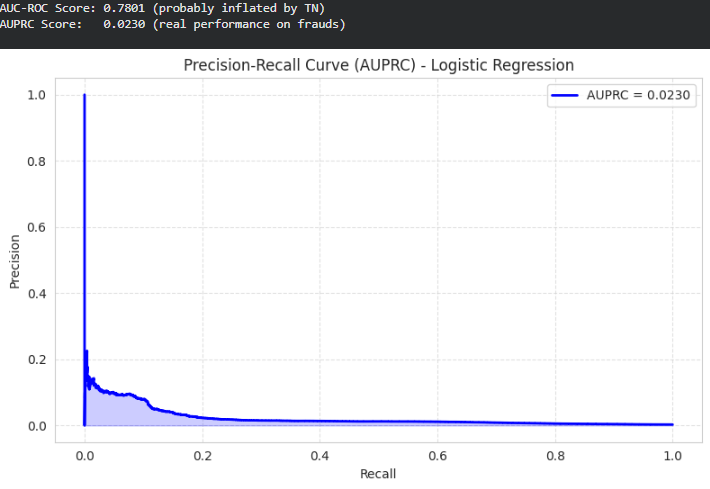



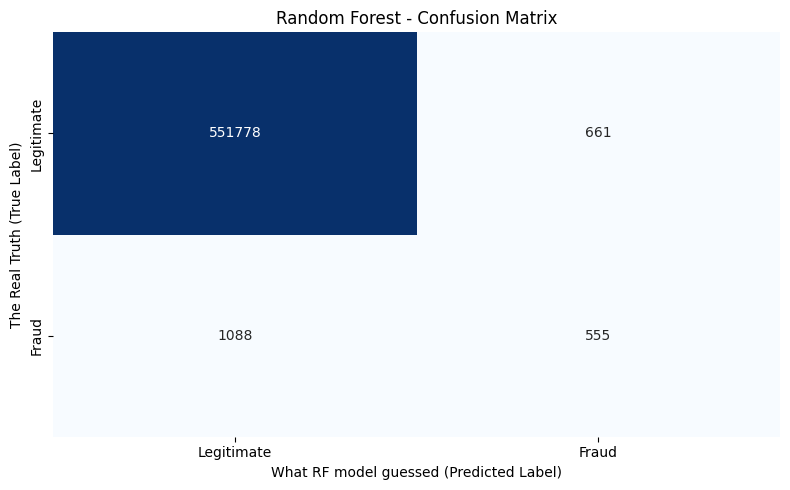


Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    552439
       Fraud       0.46      0.34      0.39      1643

    accuracy                           1.00    554082
   macro avg       0.73      0.67      0.69    554082
weighted avg       1.00      1.00      1.00    554082

AUC-ROC Score: 0.7508 (probably inflated by TN)
AUPRC Score:   0.3447 (real performance on frauds)



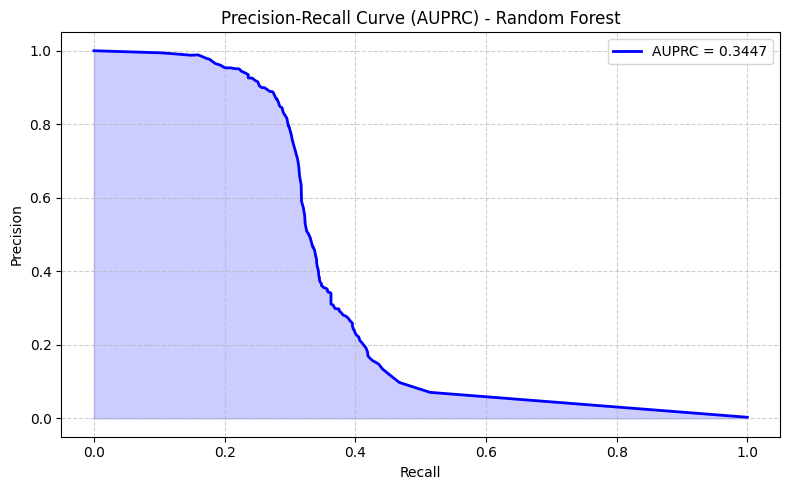

In [ ]:
#RANDOM FOREST

#Train the RF model
#set "class_weight=balanced" helps the RF model to automatically determine the right penalty to give the model when it makes a mistake
#and set "n_estimators=100" means the model will build a forest of 100 decision trees
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

#RF has to learn how to spot frauds
rf.fit(X_train, y_train)

#Predictions
y_pred_rf = rf.predict(X_test)

# Probabilities (the model's confidence scores) --> we need them for the AUPRC
y_prob_rf = rf.predict_proba(X_test)[:, 1]

#Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 5))
class_labels = ["Legitimate", "Fraud"]
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("What RF model guessed (Predicted Label)")
plt.ylabel("The Real Truth (True Label)")
plt.tight_layout()
plt.show()

#Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=["Legitimate", "Fraud"]))

#AUC & AUPRC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
auprc_score_rf = average_precision_score(y_test, y_prob_rf)
print(f"AUC-ROC Score: {roc_auc_rf:.4f} (probably inflated by TN)")
print(f"AUPRC Score:   {auprc_score_rf:.4f} (real performance on frauds)\n")

#Chart of AUPRC Curve
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))
plt.plot(recall_rf, precision_rf, color="blue", lw=2, label=f'AUPRC = {auprc_score_rf:.4f}')
plt.fill_between(recall_rf, precision_rf, alpha=0.2, color="blue")
plt.title("Precision-Recall Curve (AUPRC) - Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Random Forest Results**

As shown in the Confusion Matrix above, the Random Forest model behaves very differently from the previous Logistic Regression model.
The biggest improvement is the large reduction in false positives (661). Compared to the 124349 false alarms from Logistic Regression, Random Forest is much more conservative. It rarely blocks legitimate transactions, which leads to a much better customer experience.
However, this cautious approach has a downside. Out of all the fraudulent transactions, the model correctly identified 555 (True Positives) but missed 1088 (False Negatives).

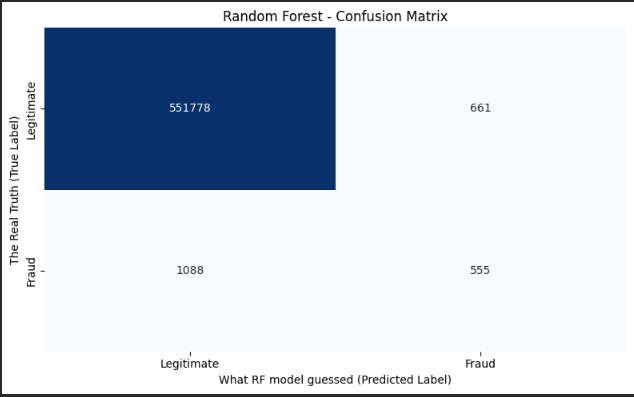



**Classification Report**:

* Precision (0.46): this is a major improvement. Previously, only 1% of flagged transactions were actually fraud. Now, the Random Forest is correct about 46% of the time, meaning false alarms are much more under control

* Recall (0.34): this is still a weak point. To reduce false alarms, the model misses many fraudulent transactions. It detects only 34% of actual fraud

* F1-Score (0.39): despite the lower Recall, the F1-score is significantly higher than with Logistic Regression (0.02). This indicates a much better balance between Precision and Recall

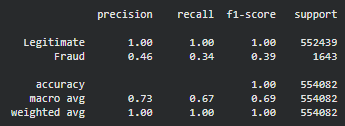

Finally, the Precision-Recall Curve shows a clear improvement compared to Logistic Regression. **The AUPRC score of 0.3447 confirms that the Random Forest handles this imbalanced dataset much better**.

At the beginning, the curve stays high, meaning the model can correctly detect about 35% of fraud cases with few errors. However, the curve drops quickly after that point. This means that if we try to catch more fraud (higher Recall), the model starts making more mistakes and produces more false alarms (lower Precision).

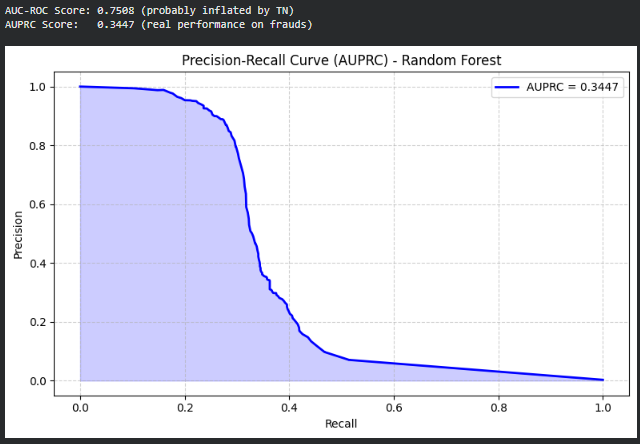


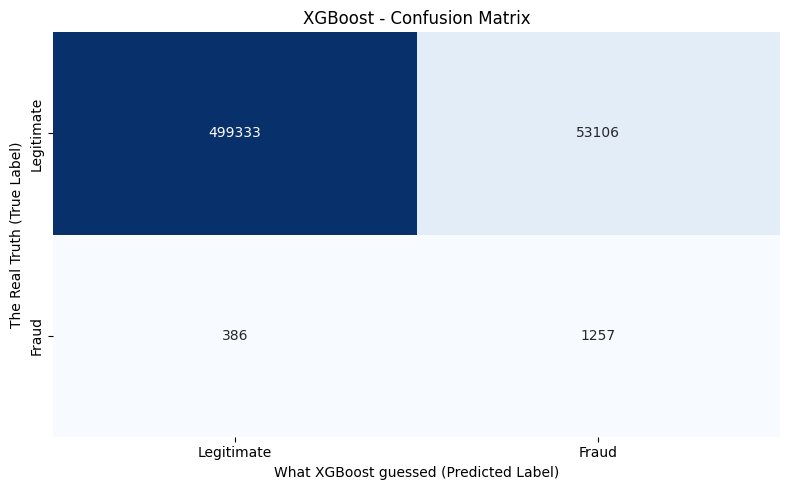


Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.90      0.95    552439
       Fraud       0.02      0.77      0.04      1643

    accuracy                           0.90    554082
   macro avg       0.51      0.83      0.50    554082
weighted avg       1.00      0.90      0.95    554082

AUC-ROC Score: 0.9090 (probably inflated by TN)
AUPRC Score:   0.4181 (real performance on frauds)



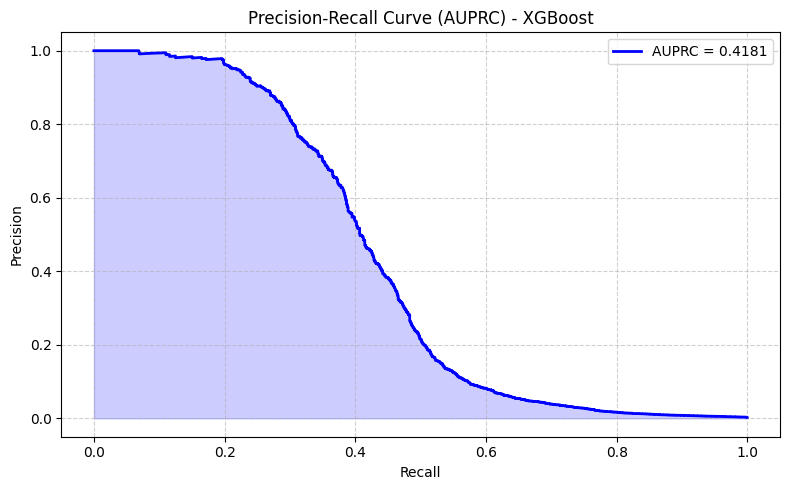

In [ ]:
#XGBOOST (Gradient Boosting)

#Calculate the weight to balance the classes (Number of Legitimate/Number of Frauds in the Training set) --> this value sys "one fraud is worth as much as X normal transactions"
weight_classes = sum(y_train == 0) / sum(y_train == 1)

#Train the XGBoost model
xgb = XGBClassifier(scale_pos_weight=weight classes, random_state=42, eval_metric="logloss")

#XGBoost has to learn how to spot frauds
xgb.fit(X_train, y_train)

#Predictions
y_pred_xgb = xgb.predict(X_test)

#Probabilities (the model's confidence scores) --> we need them for the AUPRC
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

#Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 5))
class_labels = ["Legitimate", "Fraud"]
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("What XGBoost guessed (Predicted Label)")
plt.ylabel("The Real Truth (True Label)")
plt.tight_layout()
plt.show()

#Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=["Legitimate", "Fraud"]))

#AUC & AUPRC
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
auprc_score_xgb = average_precision_score(y_test, y_prob_xgb)

print(f"AUC-ROC Score: {roc_auc_xgb:.4f} (probably inflated by TN)")
print(f"AUPRC Score:   {auprc_score_xgb:.4f} (real performance on frauds)\n")

#Chart of AUPRC Curve
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 5))
plt.plot(recall_xgb, precision_xgb, color="blue", lw=2, label=f'AUPRC = {auprc_score_xgb:.4f}')
plt.fill_between(recall_xgb, precision_xgb, alpha=0.2, color="blue")
plt.title("Precision-Recall Curve (AUPRC) - XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**XGBoost Results**

As shown in the Confusion Matrix above, the most important improvement is XGBoost’s ability to detect fraud. Out of all fraudulent transactions, the model correctly identified 1257 (True Positives) and missed only 386 (False Negatives).

Compared to the Random Forest, which missed over 1088 fraud cases due to its cautious approach, XGBoost performs much better as a “fraud hunter,” achieving the highest Recall.

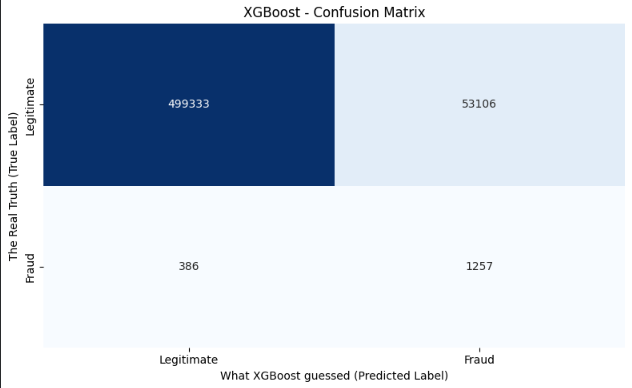

**Classification Report**:

* Precision (0.02): precision dropped back to 2%. Unlike the Random Forest, when XGBoost flags a transaction as fraud, it is only right 2% of the time because of the high number of false alarms it generates to stay safe

* Recall (0.77): the model catches 77% of all actual frauds, which is the highest detection rate we have achieved

* F1-Score (0.04): because the Precision dropped so much, the F1-Score fell back down to 0.04. However, as we know from our AUPRC analysis (0.41), XGBoost is still our strongest model overall because it gives us the best potential to balance these numbers if we adjust the threshold


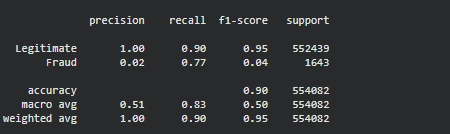

Finally, **the Precision-Recall Curve shows our best result yet. The AUPRC score of 0.4181 confirms that XGBoost is the strongest model we tested for this highly unbalanced dataset, beating both Logistic Regression (0.02) and Random Forest (0.34)**.

Looking at the graph, we can see that the curve is "pushed" to the right compared to the Random Forest. The drop is much smoother and less aggressive. For example, even if we push the model to catch 40% of all frauds (Recall of 0.4), the Precision is still around 50% (0.5). This means XGBoost is much smarter at finding the tricky, hidden frauds before it starts making mistakes and generating massive false alarms.

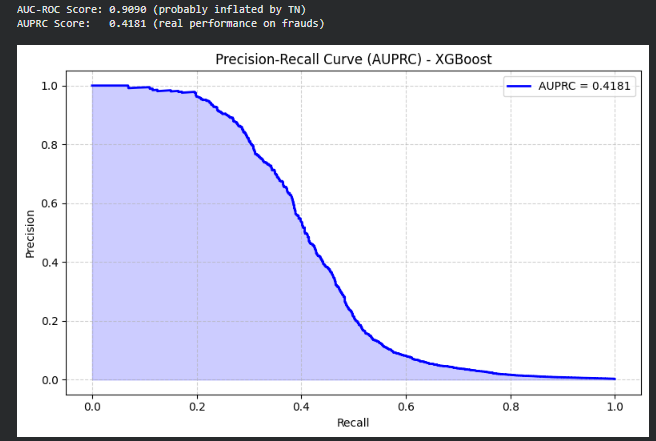


**Conclusion**

We tested three different models for detecting credit card fraud. Logistic Regression performed poorly because it generated too many false alarms (AUPRC = 0.02). Random Forest reduced false alarms but missed many real fraud cases (AUPRC = 0.34). **XGBoost is the best model overall, achieving the highest AUPRC score of 0.41**.

Even though XGBoost has a low F1-score (0.04), it is still the best choice. This is because metrics like the F1-score rely on a fixed threshold: a transaction is flagged as fraud only if the model is more than 50% confident. In highly imbalanced datasets, this 50% threshold is not effective. The Precision-Recall Curve (AUPRC) is more useful because it evaluates performance across all possible thresholds, not just one. The high AUPRC of 0.4181 shows that XGBoost is actually very good at identifying fraud. If needed, we can improve the F1-score later by adjusting the threshold.


